# 멀티모달 AI Agent

## 1.환경준비

### (1) 라이브러리 설치

In [ ]:
!pip -q install langgraph pillow -q

### (2) 라이브러리 로딩

In [ ]:
import os, base64, io, requests, json
from typing import Annotated, TypedDict, List
from PIL import Image

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool

from openai import OpenAI

### (3) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (4) OpenAI API Key 등록
* 환경변수로 key 등록

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [ ]:
print(os.environ['OPENAI_API_KEY'][:40])

## 2.Agent 구성해보기

* 다음과 같은 그래프로 Agent를 구성해 봅시다.

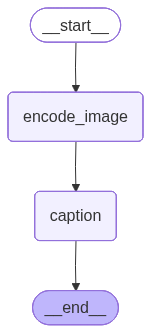

### (1) State 정의

In [ ]:
# OpenAI client 선언
client = OpenAI()

In [ ]:
class State(TypedDict):
    prompt: str
    image_path: str
    image_b64: str
    caption: str

### (2) 노드 함수

* 이미지 변환 함수

In [ ]:
def b64_encoding(path: str) -> str:
    with open(path, "rb") as f:
        b = f.read()
    b64 = base64.b64encode(b).decode()  # base64로 인코딩한 뒤, bytes → str로 디코딩해 문자열을 얻음
    # MIME은 간단히 png/jpg만 케이스 분기
    ext = path.lower().split(".")[-1]   # 파일 확장자를 소문자로 뽑아냄
    mime = "image/png" if ext=="png" else "image/jpeg"
    return f"data:{mime};base64,{b64}"  # Data URI 형식으로 문자열을 만들어 반환

* 노드 구현

In [ ]:
# 노드1: base64 인코딩
def encode_image(state: State) -> State:
    state["image_b64"] = b64_encoding(state["image_path"])
    return state

# 노드2: gpt-4o-mini 캡셔닝
def caption_with_gpt4o(state: State) -> State:
    messages = [{"role": "system", "content": "너는 이미지 캡션을 만드는 전문가야."},
                {"role": "user",
                 "content": [{"type": "text", "text": state["prompt"]},
                             {"type": "image_url", "image_url": {"url": state["image_b64"]}}
                            ]}
                ]

    model = client.chat.completions.create(
        model = "gpt-4o-mini",
        messages = messages,
        temperature = 0.3,
        max_tokens = 60,
    )

    state["caption"] = model.choices[0].message.content
    return state

### (3) 그래프 구성

In [ ]:
# 그래프 구성
graph = StateGraph(State)
graph.add_node("encode_image", encode_image)
graph.add_node("caption", caption_with_gpt4o)

graph.add_edge(START, "encode_image")
graph.add_edge("encode_image", "caption")
graph.add_edge("caption", END)

basic_app = graph.compile()

In [ ]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(basic_app.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) 실행

* 파일 업로드

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 image_sonny.jpg 선택

In [ ]:
state0 = {"prompt": "이미지를 한국어 한 문장으로만 출력해.",
          "image_path": "image_sonny.jpg"}
final_state = basic_app.invoke(state0)

In [ ]:
final_state

In [ ]:
from IPython.display import display, HTML

image_src = final_state.get("image_b64")
cap = final_state.get("caption")

display(HTML(f"""
<figure style="text-align:left">
  <img src="{image_src}" style="max-width:560px;height:auto;" />
  <figcaption style="margin-top:8px;font-size:16px">{cap}</figcaption>
</figure>
"""))

## 3.실습
* 개요 : 그래프 이미지를 입력받아 음성으로 설명하는 Agent를 만들어 봅시다.
* Agent 구성
    * 그래프 이미지와 텍스트(지침, 그래프에 대한 최소 설명 등)를 입력으로 받아
    * 그래프를 분석하여 key point를 도출하고, 비즈니스 관점 해석
    * 분석 내용을 바탕으로 설명문 작성
    * 설명문을 음성으로 변환(TTS로 mp3 출력)

* 다음과 같은 그래프로 Agent를 구성해 봅시다.

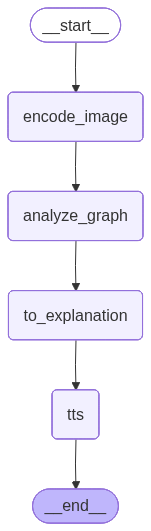

In [ ]:
from typing import TypedDict, Optional, List, Annotated, Dict, Any
from openai import OpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

import base64, json, io, os
from IPython.display import display, Audio, Image as DispImage, HTML
from PIL import Image

### (1) State 정의
* State에 담을 만한 내용을 적절하게 구성합니다.

In [ ]:
# OpenAI client 선언


In [ ]:
class State(TypedDict):
    messages: List[dict]                 # OpenAI 스타일 메시지 로그
    prompt: str                # 사용자 프롬프트(분석 스타일 지시)
    image_path: str
    image_b64: str
    analysis: str
    explanation: str           # 최종 설명문(음성 합성용)
    audio_path: str          # 생성된 오디오 파일 경로

### (2) 노드 함수
* 이미지 변환 함수는 제공합니다.

In [ ]:
def b64_encoding(path: str) -> str:
    with open(path, "rb") as f:
        b = f.read()
    b64 = base64.b64encode(b).decode()  # base64로 인코딩한 뒤, bytes → str로 디코딩해 문자열을 얻음
    # MIME은 간단히 png/jpg만 케이스 분기
    ext = path.lower().split(".")[-1]   # 파일 확장자를 소문자로 뽑아냄
    mime = "image/png" if ext=="png" else "image/jpeg"
    return f"data:{mime};base64,{b64}"  # Data URI 형식으로 문자열을 만들어 반환

* 필요 노드 : 이미지 인코딩, 차트 분석, 설명문으로 정리, 음성변환

In [ ]:
# base64 인코딩
def encode_image(state: State) -> State:


    return state

# 그래프 분석 (gpt-4o-mini 멀티모달)
def analyze_graph(state: State) -> State:


    return state

# 설명문 생성
def to_explanation(state: State) -> State:


    return state

# 음성 합성(gpt-4o-mini-tts)
def tts_with_gpt4o(state: State) -> State:


    return state

### (3) 그래프 구성

In [ ]:
# 그래프 구성
graph = StateGraph(State)





basic_app = graph.compile()

In [ ]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(basic_app.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) 실행

* 파일 업로드

In [ ]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 scatterplot1.jpg 선택

In [ ]:
state0 = {"prompt": "# 그래프 기본 설명 : price와 sales의 관계",
          "image_path": "scatterplot1.png" }

final_state = basic_app.invoke(state0)

In [ ]:
final_state

In [ ]:
image_src = final_state.get("image_b64")
display(HTML(f"""
<figure style="text-align:left">
  <img src="{image_src}" style="max-width:560px;height:auto;" />
</figure>
"""))

print("\n설명문:\n")
print(final_state.get("analysis","(설명 없음)"))

if final_state.get("audio_path") and os.path.exists(final_state["audio_path"]):
    display(Audio(filename=final_state["audio_path"], autoplay=False))
else:
    print("\n오디오 파일 생성 실패 또는 경로 없음:", final_state.get("audio_path"))